# Exploratory Data Analysis (EDA)

## Objective

The purpose of this notebook is to explore the cleaned infrared thermography dataset through statistical summaries and visualizations.

The insights obtained from this analysis will guide feature engineering, model selection, and interpretation.

In [31]:
# Load libraries
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from pandas.api.types import CategoricalDtype

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("ggplot")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load Dataset
df = pd.read_csv("../data/cleaned.csv")

df.head()

,Gender,Age,Ethnicity,T_atm,Humidity,Distance,T_offset1,Max1R13_1,Max1L13_1,aveAllR13_1,aveAllL13_1,T_RC1,T_RC_Dry1,T_RC_Wet1,T_RC_Max1,T_LC1,T_LC_Dry1,T_LC_Wet1,T_LC_Max1,RCC1,LCC1,canthiMax1,canthi4Max1,T_FHCC1,T_FHRC1,T_FHLC1,T_FHBC1,T_FHTC1,T_FH_Max1,T_FHC_Max1,T_Max1,T_OR1,T_OR_Max1,aveOralF
0,Male,41-50,White,24.0,28.0,0.8,0.7025,35.0300,35.3775,34.4000,34.9175,34.9850,34.9850,34.7625,35.0325,35.3375,35.3375,34.4850,35.3775,34.7850,34.4650,35.3775,35.3375,33.5775,33.4775,33.3725,33.4925,33.0025,34.5300,34.0075,35.6925,35.6350,35.6525,36.85
1,Female,31-40,Black or African-American,24.0,26.0,0.8,0.7800,34.5500,34.5200,33.9300,34.2250,34.7100,34.6325,34.6400,34.7425,34.5600,34.5375,34.3500,34.5750,34.3225,34.2400,34.7400,34.7150,34.0325,34.0550,33.6775,33.9700,34.0025,34.6825,34.6600,35.1750,35.0925,35.1075,37.00
2,Female,21-30,White,24.0,26.0,0.8,0.8625,35.6525,35.5175,34.2775,34.8000,35.6850,35.6675,35.6150,35.7175,35.5025,35.5025,35.2950,35.5300,35.3575,35.0925,35.7175,35.6825,34.9000,34.8275,34.6475,34.8200,34.6700,35.3450,35.2225,35.9125,35.8600,35.8850,37.20
3,Female,21-30,Black or African-American,24.0,27.0,0.8,0.9300,35.2225,35.6125,34.3850,35.2475,35.2075,35.2000,35.1175,35.2250,35.5950,35.5950,35.3275,35.6125,34.9100,35.1700,35.6125,35.5950,34.4400,34.4225,34.6550,34.3025,34.9175,35.6025,35.3150,35.7200,34.9650,34.9825,36.85
4,Male,18-20,White,24.0,27.0,0.8,0.8950,35.5450,35.6650,34.9100,35.3675,35.6025,35.4750,35.5700,35.6400,35.6400,35.6400,35.0775,35.6675,35.3550,35.1200,35.6650,35.6475,35.0900,35.1600,34.3975,34.6700,33.8275,35.4175,35.3725,35.8950,35.5875,35.6175,36.80


In [3]:
# Dataset Shape
rows, cols = df.shape

print(f"Rows: {rows}")
print(f"Columns: {cols}")

Rows: 1020
Columns: 34


In [4]:
# Target = aveOralF
df["aveOralF"].describe()

count    1020.000000
mean       36.979216
std         0.386403
min        35.750000
25%        36.800000
50%        36.900000
75%        37.100000
max        39.600000
Name: aveOralF, dtype: float64

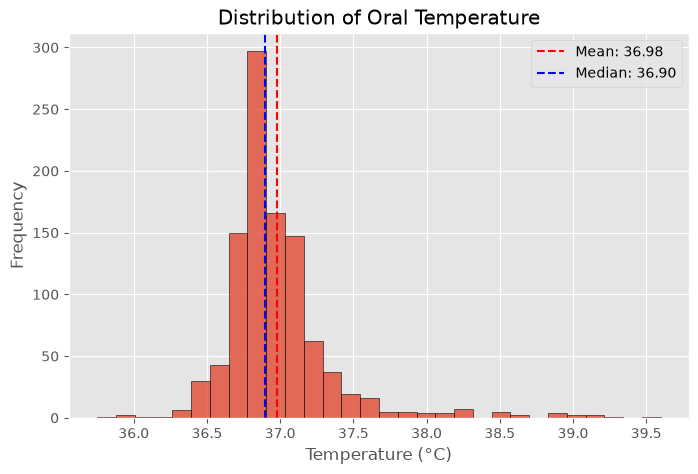

In [23]:
# Histogram
plt.figure(figsize=(8,5))

plt.hist(
    df["aveOralF"],
    bins=30,
    edgecolor="black",
    alpha=0.8
)

plt.axvline(
    df["aveOralF"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {df['aveOralF'].mean():.2f}"
)

plt.axvline(
    df["aveOralF"].median(),
    color="blue",
    linestyle="--",
    label=f"Median: {df['aveOralF'].median():.2f}"
)

plt.title("Distribution of Oral Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.legend()

plt.show()

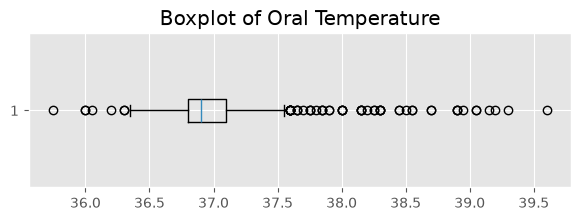

In [6]:
# Boxplot
plt.figure(figsize=(7,2))

plt.boxplot(df["aveOralF"], vert=False)

plt.title("Boxplot of Oral Temperature")

plt.show()

### Observation

Most oral temperature measurements fall within a narrow range around 36.9°C.

Several higher-temperature observations are present, extending beyond 38°C. These may represent individuals with elevated body temperatures rather than data errors.

The outliers will be retained because they may contain clinically meaningful information.

In [7]:
# Numerical Feature Distribution
numerical_columns = df.select_dtypes(include=["float64", "int64"]).columns

In [9]:
# Droping target
numerical_columns = numerical_columns.drop(["aveOralF"])

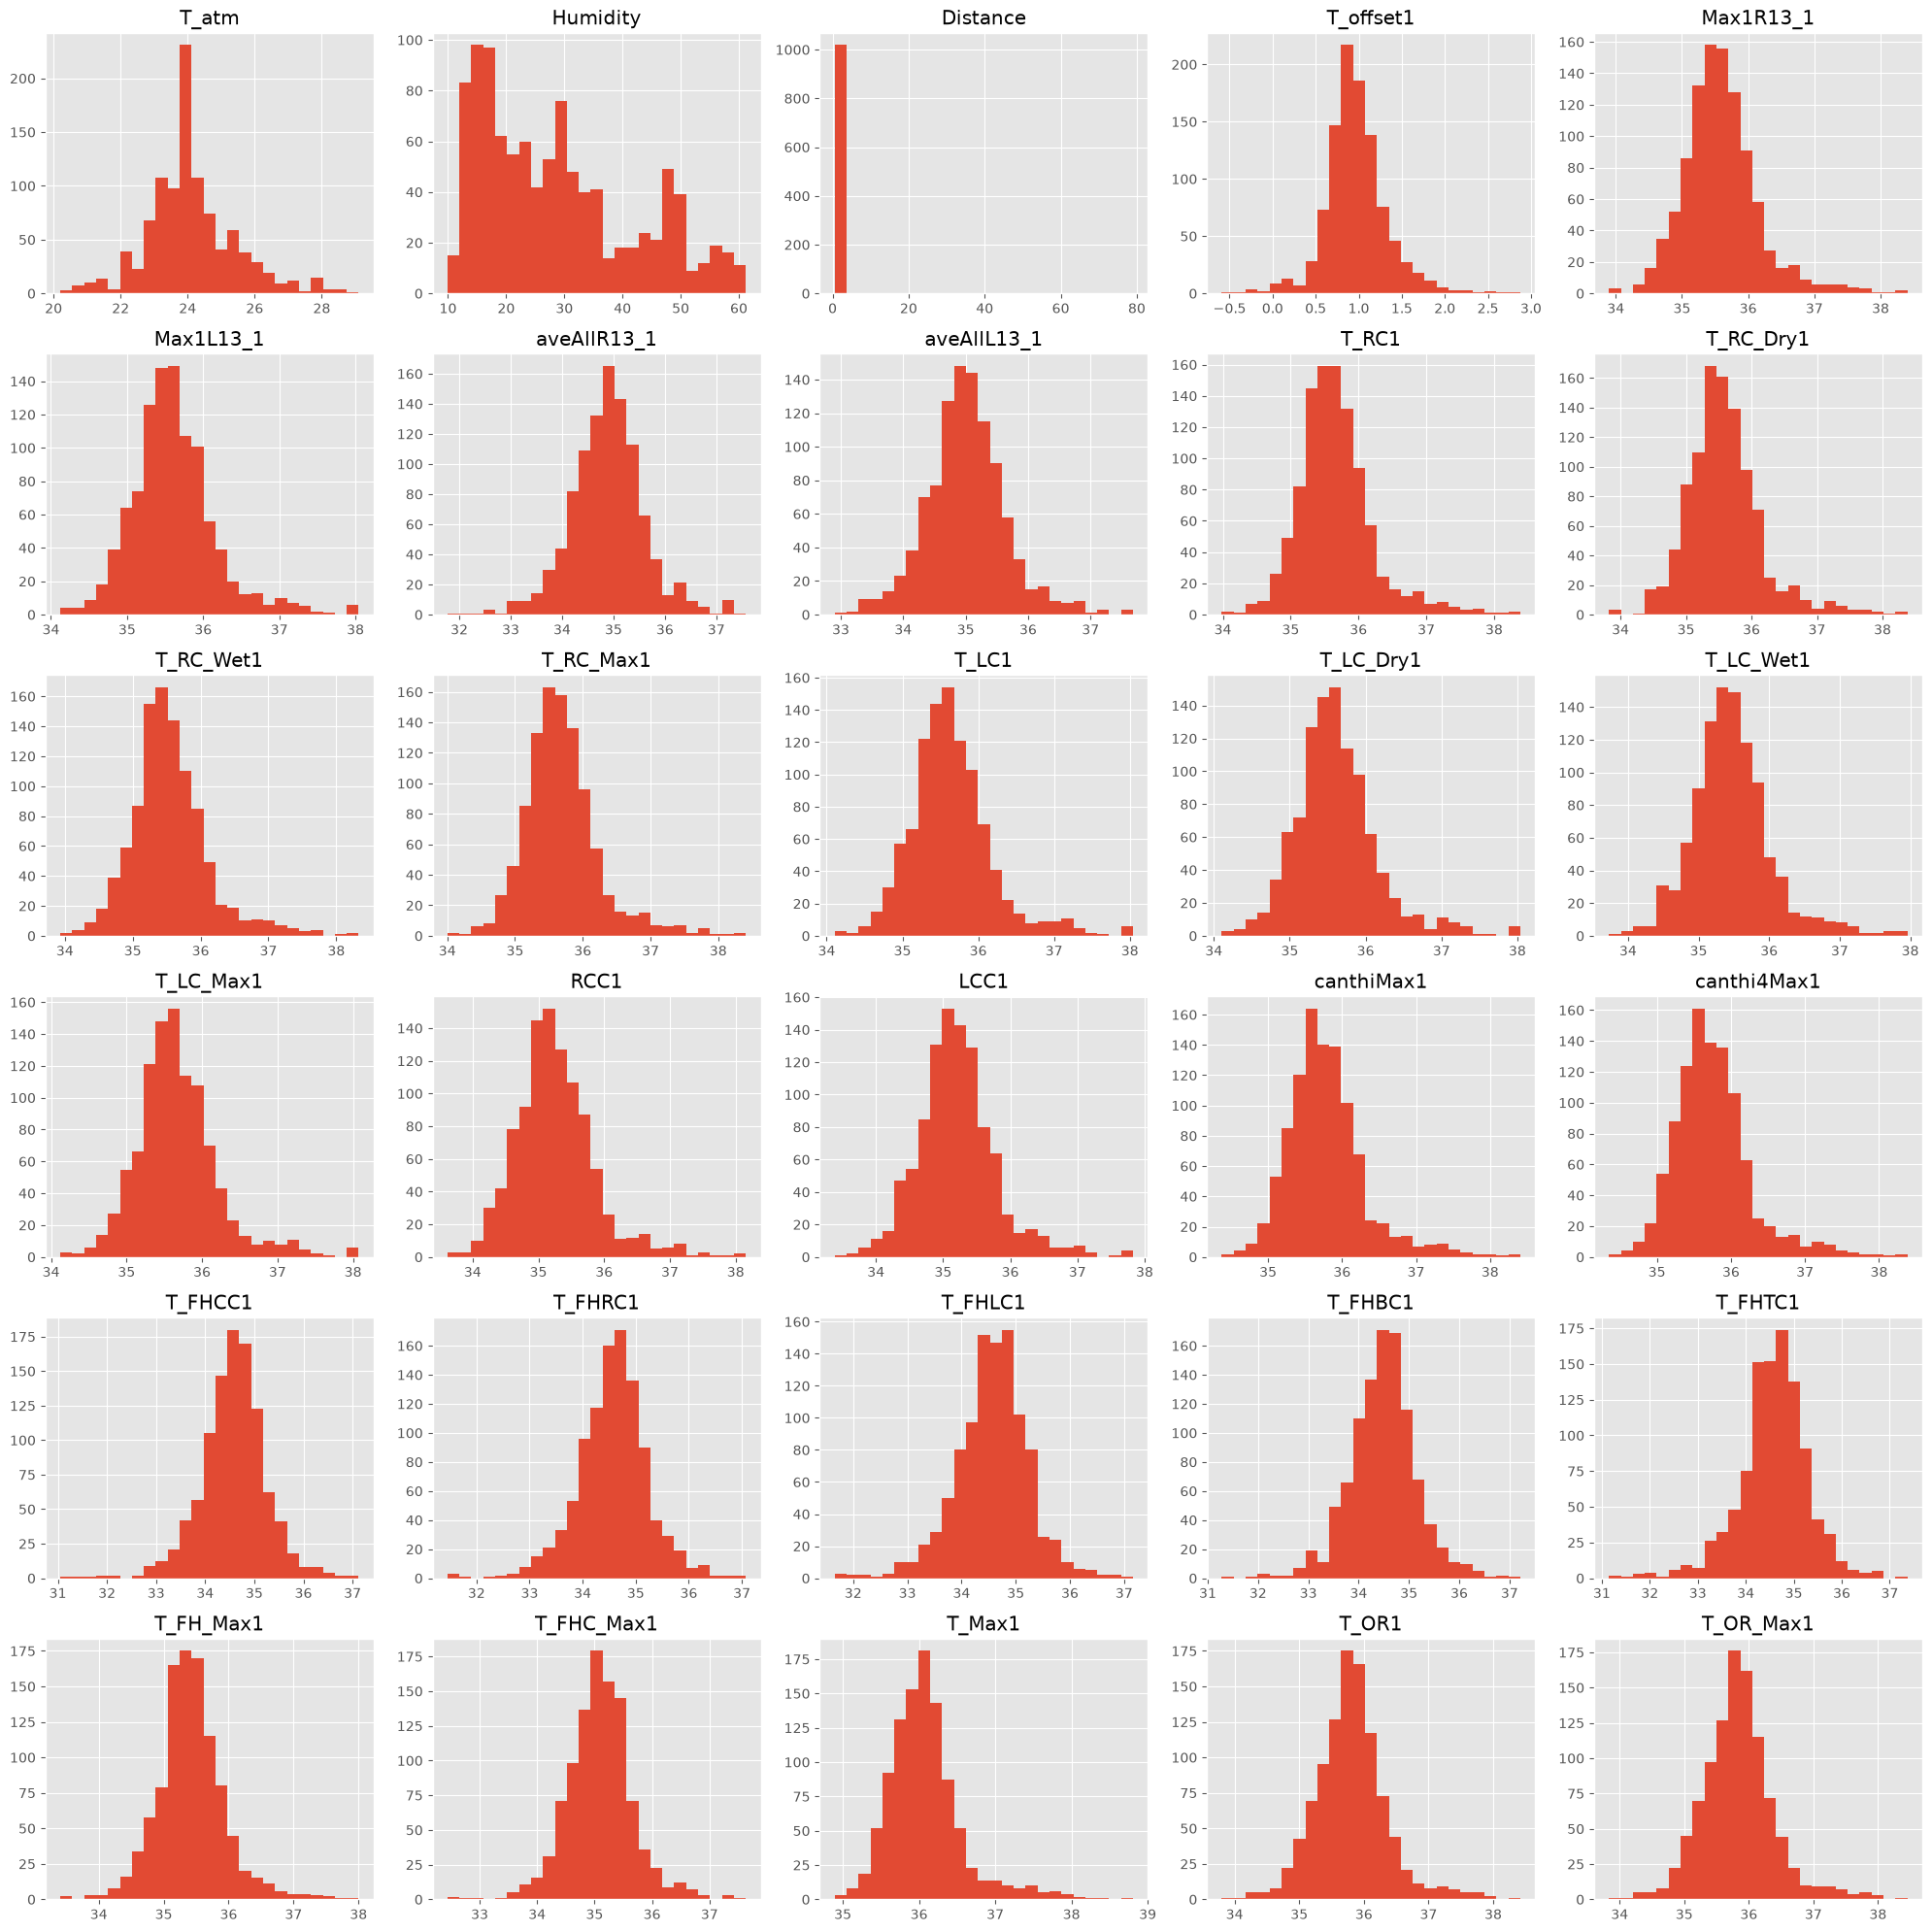

In [10]:
df[numerical_columns].hist(
    figsize=(20,20),
    bins=25
)

plt.tight_layout()

plt.show()

In [11]:
# Categorical Features: Gender
df["Gender"].value_counts()

Gender
Female    606
Male      414
Name: count, dtype: int64

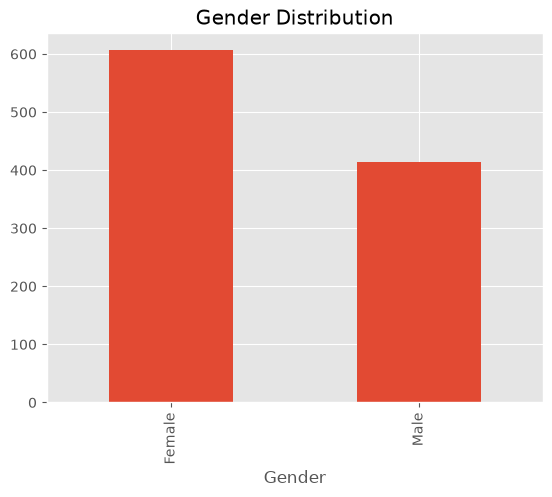

In [12]:
df["Gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")

plt.show()

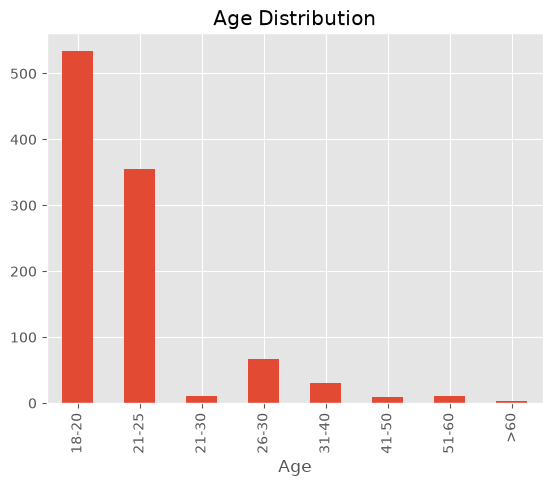

In [13]:
# Age
df["Age"].value_counts().sort_index().plot(kind="bar")

plt.title("Age Distribution")

plt.show()

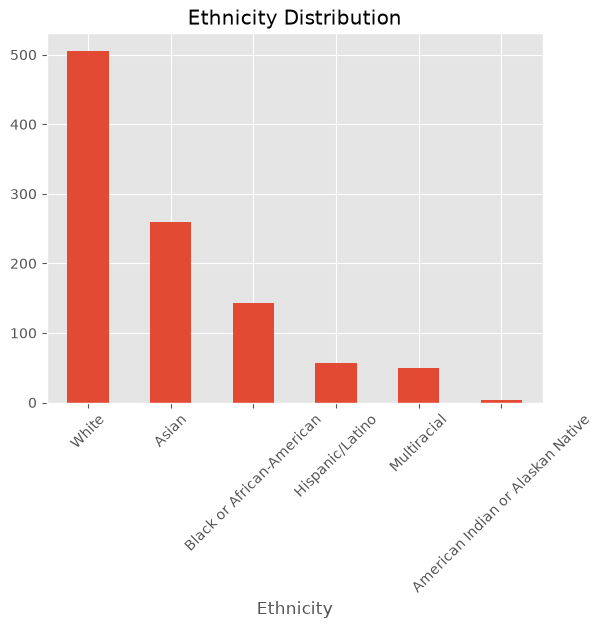

In [14]:
# Ethnicity
df["Ethnicity"].value_counts().plot(kind="bar")

plt.title("Ethnicity Distribution")

plt.xticks(rotation=45)

plt.show()

### Observation

Male and female participants exhibit similar oral temperature distributions.

No substantial difference in median temperature is observed between the two groups, suggesting that gender alone may not strongly influence oral temperature.

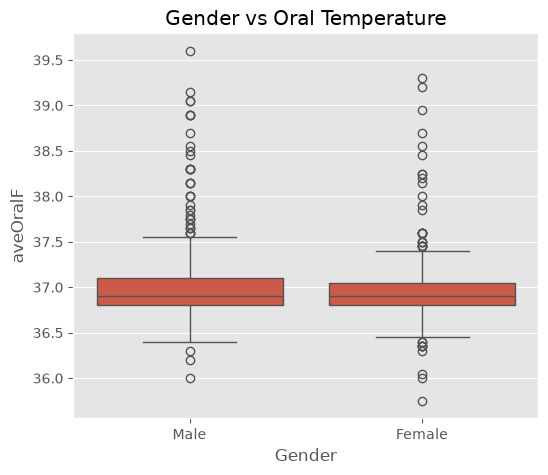

In [15]:
# Relationship Between Categories(Gender) and Target(Oral Temperature)
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x="Gender",
    y="aveOralF"
)

plt.title("Gender vs Oral Temperature")

plt.show()

## Preparing the Age Feature

The dataset contains overlapping age categories (e.g., `21-25`, `21-30`, and `26-30`).

To improve visualization readability, the age categories are converted into an ordered categorical variable. This does not modify the underlying data; it only controls the display order in plots.

In [32]:
age_order = [
    "18-20",
    "21-25",
    "21-30",
    "26-30",
    "31-40",
    "41-50",
    "51-60",
    ">60"
]

# Convert Age to an ordered categorical variable
age_type = CategoricalDtype(categories=age_order, ordered=True)

df["Age"] = df["Age"].astype(age_type)

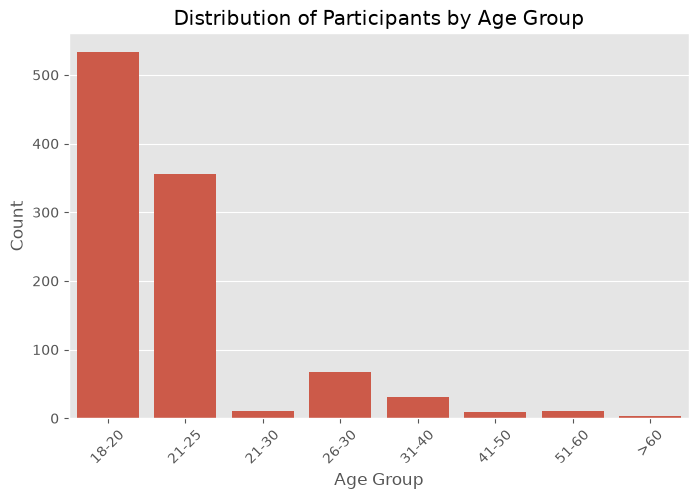

In [33]:
# Age vs Temperature
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Age",
    order=age_order
)

plt.title("Distribution of Participants by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

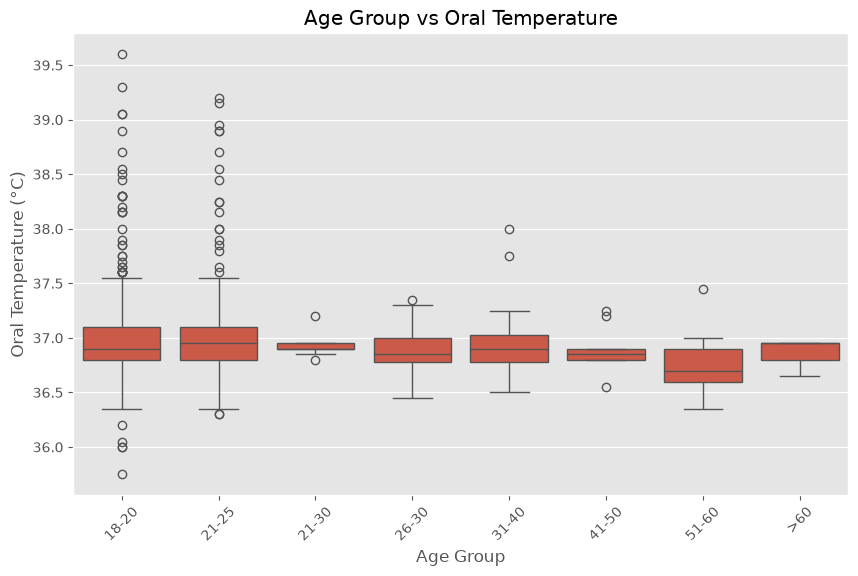

In [34]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Age",
    y="aveOralF",
    order=age_order
)

plt.title("Age Group vs Oral Temperature")
plt.xlabel("Age Group")
plt.ylabel("Oral Temperature (°C)")
plt.xticks(rotation=45)

plt.show()

### Observation

Median oral temperatures are broadly similar across ethnic groups.

Differences between groups appear small, indicating that ethnicity alone may have limited predictive power.

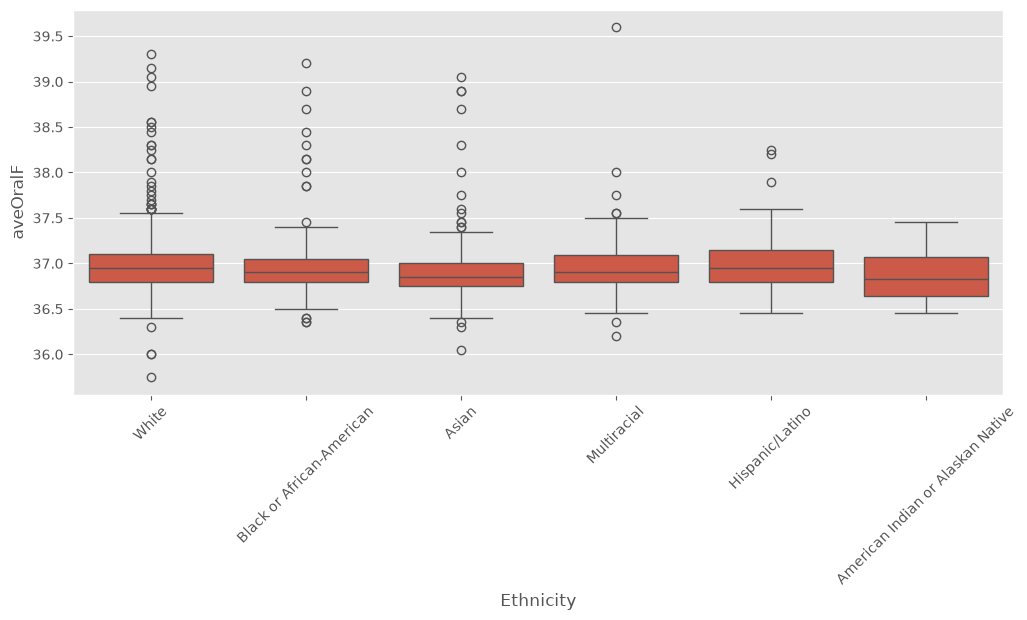

In [17]:
# Ethnicity vs Temperature
plt.figure(figsize=(12,5))

sns.boxplot(
    data=df,
    x="Ethnicity",
    y="aveOralF"
)

plt.xticks(rotation=45)

plt.show()

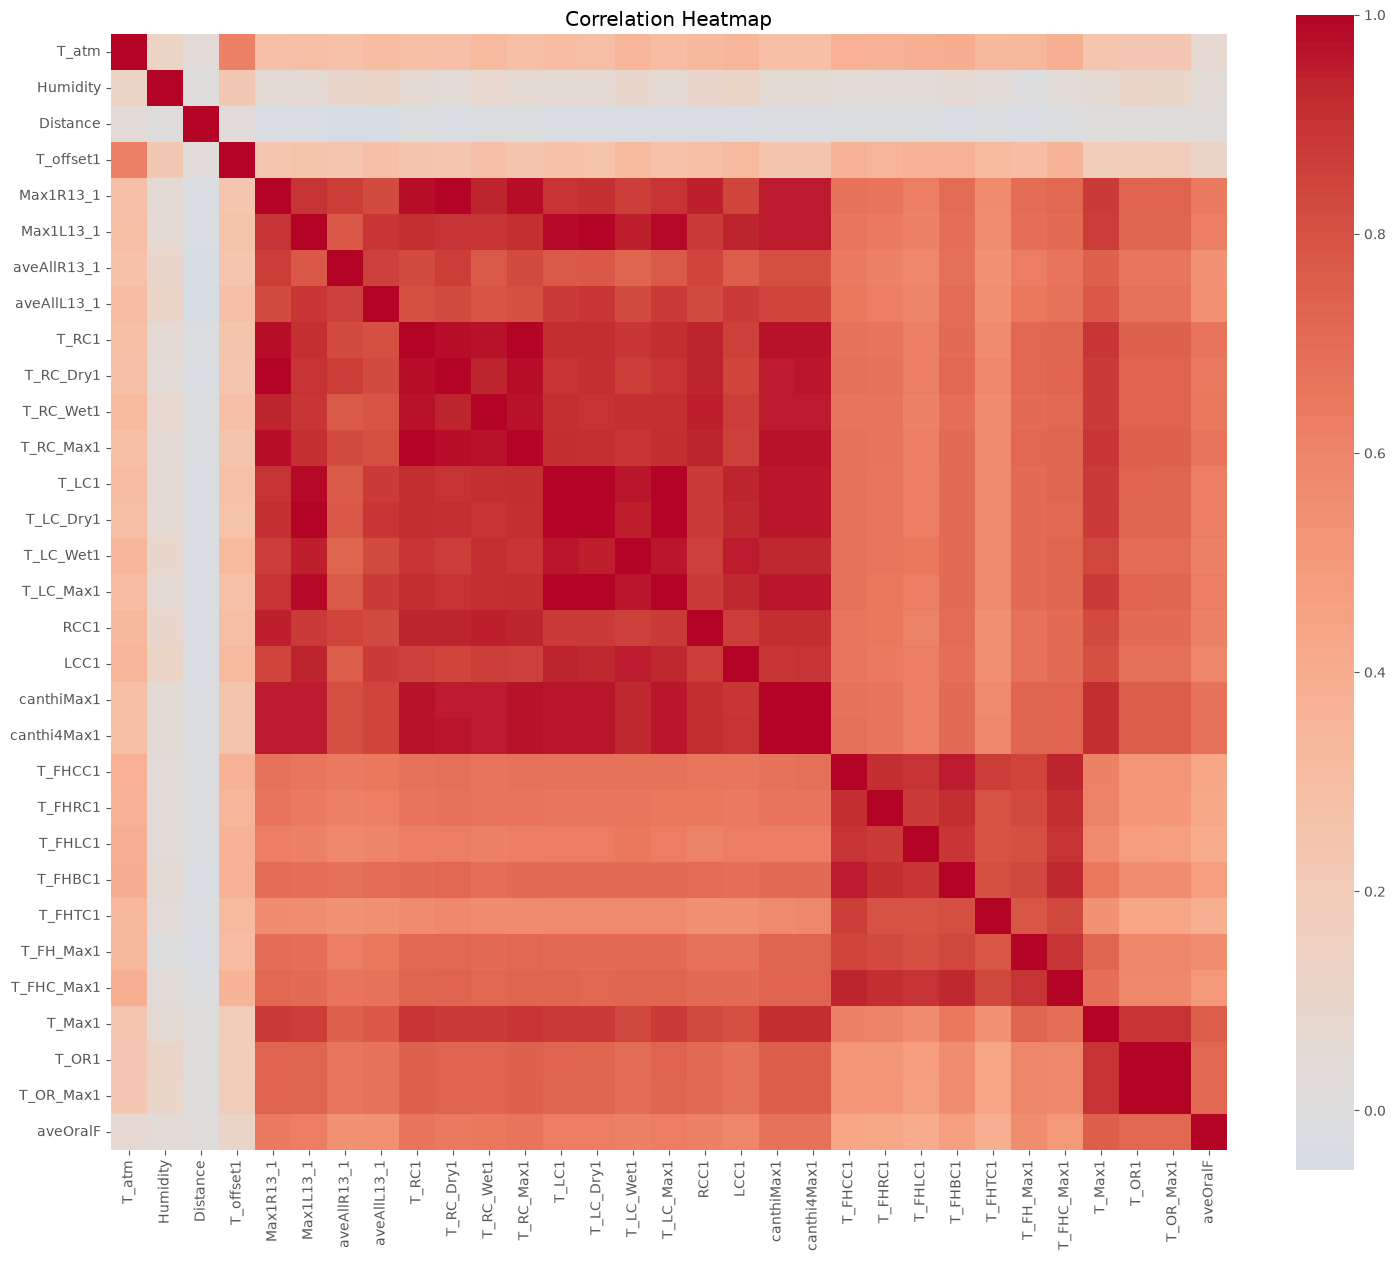

In [36]:
# Correlation Analysis
corr = df.corr(numeric_only=True)

plt.figure(figsize=(18,15))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Heatmap")

plt.show()

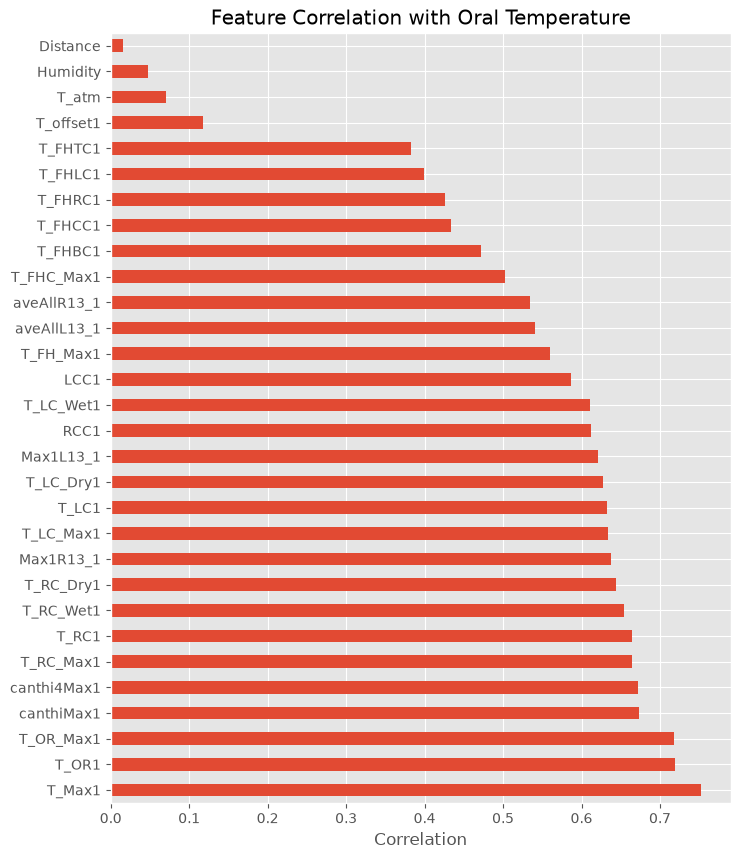

In [37]:
corr = df.corr(numeric_only=True)

target_corr = (
    corr["aveOralF"]
    .drop("aveOralF")
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,10))

target_corr.plot(kind="barh")

plt.title("Feature Correlation with Oral Temperature")

plt.xlabel("Correlation")

plt.show()

In [20]:
# Features that correlate must with target
correlation["aveOralF"]\
.sort_values(ascending=False)

aveOralF       1.000000
T_Max1         0.752546
T_OR1          0.718840
T_OR_Max1      0.718513
canthiMax1     0.673136
canthi4Max1    0.672514
T_RC_Max1      0.664864
T_RC1          0.664154
T_RC_Wet1      0.654099
T_RC_Dry1      0.643588
Max1R13_1      0.637134
T_LC_Max1      0.633186
T_LC1          0.633009
T_LC_Dry1      0.627341
Max1L13_1      0.621410
RCC1           0.611695
T_LC_Wet1      0.611027
LCC1           0.586546
T_FH_Max1      0.560117
aveAllL13_1    0.540581
aveAllR13_1    0.534192
T_FHC_Max1     0.502194
T_FHBC1        0.472456
T_FHCC1        0.433403
T_FHRC1        0.425942
T_FHLC1        0.399649
T_FHTC1        0.382936
T_offset1      0.117794
T_atm          0.070825
Humidity       0.047200
Distance       0.016112
Name: aveOralF, dtype: float64

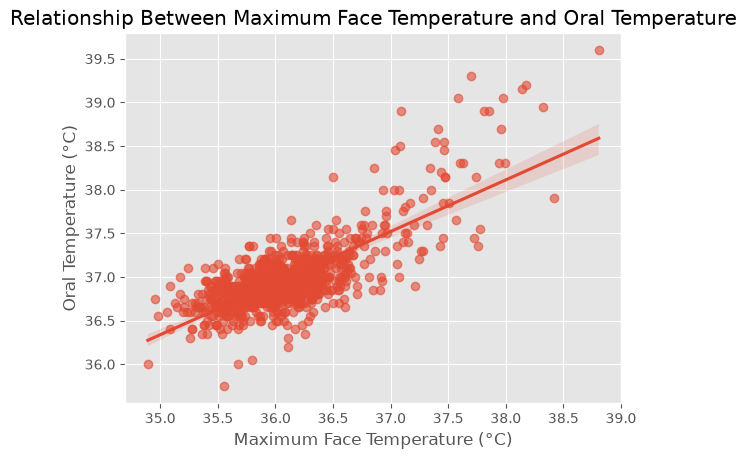

In [35]:
# Scatter plot
sns.regplot(
    data=df,
    x="T_Max1",
    y="aveOralF",
    scatter_kws={"alpha":0.6}
)

plt.title("Relationship Between Maximum Face Temperature and Oral Temperature")
plt.xlabel("Maximum Face Temperature (°C)")
plt.ylabel("Oral Temperature (°C)")

plt.show()

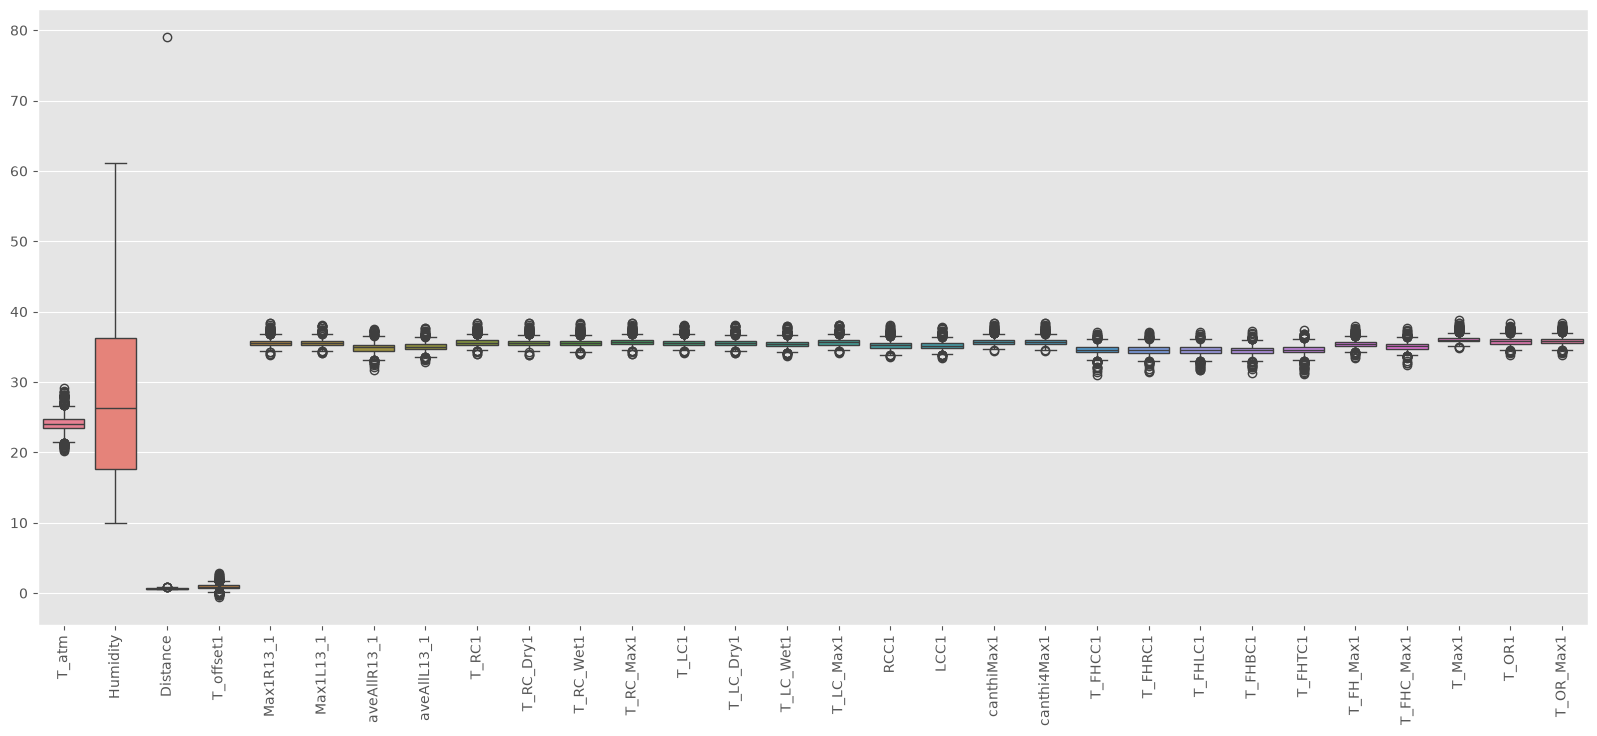

In [22]:
# Outlier Detection
plt.figure(figsize=(20,8))

sns.boxplot(
    data=df[numerical_columns]
)

plt.xticks(rotation=90)

plt.show()

In [38]:
# Top Predictors of Oral Temperature
corr = df.corr(numeric_only=True)

top_features = (
    corr["aveOralF"]
    .drop("aveOralF")
    .sort_values(ascending=False)
    .head(10)
)

print(top_features)

T_Max1         0.752546
T_OR1          0.718840
T_OR_Max1      0.718513
canthiMax1     0.673136
canthi4Max1    0.672514
T_RC_Max1      0.664864
T_RC1          0.664154
T_RC_Wet1      0.654099
T_RC_Dry1      0.643588
Max1R13_1      0.637134
Name: aveOralF, dtype: float64


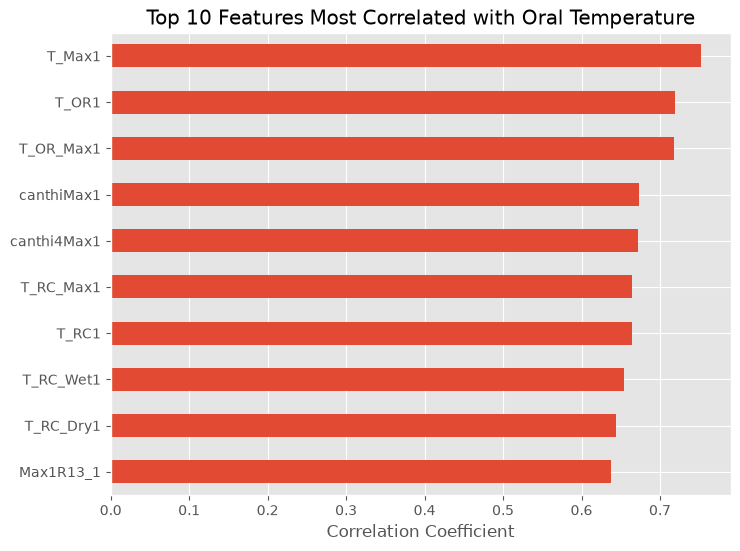

In [39]:
plt.figure(figsize=(8,6))

top_features.sort_values().plot(kind="barh")

plt.title("Top 10 Features Most Correlated with Oral Temperature")
plt.xlabel("Correlation Coefficient")

plt.show()

## Key Insights

- Oral temperature follows an approximately normal distribution.
- Distance contains no missing values after preprocessing.
- Gender appears balanced.
- Some infrared facial regions show stronger correlations with oral temperature than others.
- The maximum facial temperature (`T_Max1`) appears to be one of the strongest predictors.
- These insights will guide feature selection and model development.